In [49]:
names = open('names.txt', 'r').read().splitlines()
train = names[:len(names) * 80//100]
val = names[len(train) + 1: len(names) * 90//100]
test = names[-len(names) * 10//100:]

print(f'{len(train)=}\n{len(val)=}\n{len(test)=}')

len(train)=25626
len(val)=3202
len(test)=3204


# Training the Bi-gram model
* Training is just by calculating the maximam likelihood
* equivalent to how many times each adjacent pair occure in the corpus

In [72]:
characters = sorted(list(set(''.join(train))))

char_to_index = {c : i + 1 for i, c in enumerate(characters)}
char_to_index['.'] = 0

index_to_char = {i : c for c, i in char_to_index.items()}

In [ ]:
import torch

def train_model(n_grams, data):
    vocab_size = len(char_to_index)
    counts = torch.zeros((vocab_size,) * n_grams, dtype=torch.int32)

    for name in data:
        chars = ['.'] + list(name) + ['.']
        
        for i in range(len(chars) - n_grams + 1):
            ids = ()
            
            for j in range(n_grams):
                idx = char_to_index[chars[i + j]]
                ids += (idx,)
                
            counts[ids] += 1
    
    return counts

n_grams = 2
counts = train_model(n_grams=2, data=train)
counts

tensor([[   0, 3700, 1008, 1248, 1260, 1278,  334,  525,  688,  481, 1847, 2334,
         1330, 2115,  945,  288,  399,   67, 1319, 1668,  963,   56,  298,  234,
          102,  414,  725],
        [6411,  405,  418,  361,  839,  558,   95,  134, 2053, 1335,  125,  450,
         2199, 1293, 4328,   40,   63,   34, 2613,  823,  563,  295,  620,  104,
          126, 1684,  344],
        [  67,  215,   32,    1,   31,  545,    0,    0,   29,  171,    1,    0,
           84,    0,    2,   75,    0,    0,  686,    4,    2,   28,    0,    0,
            0,   69,    0],
        [  64,  663,    0,   30,    1,  452,    0,    1,  475,  223,    2,  223,
           93,    0,    0,  293,    1,   11,   61,    3,   29,   21,    0,    0,
            0,   88,    3],
        [ 345, 1039,    0,    1,  122,  942,    1,   16,   86,  533,    6,    1,
           53,   21,   27,  258,    0,    0,  294,   23,    1,   58,   12,   12,
            0,  263,    1],
        [3448,  592,   95,  110,  274, 1098,   56,

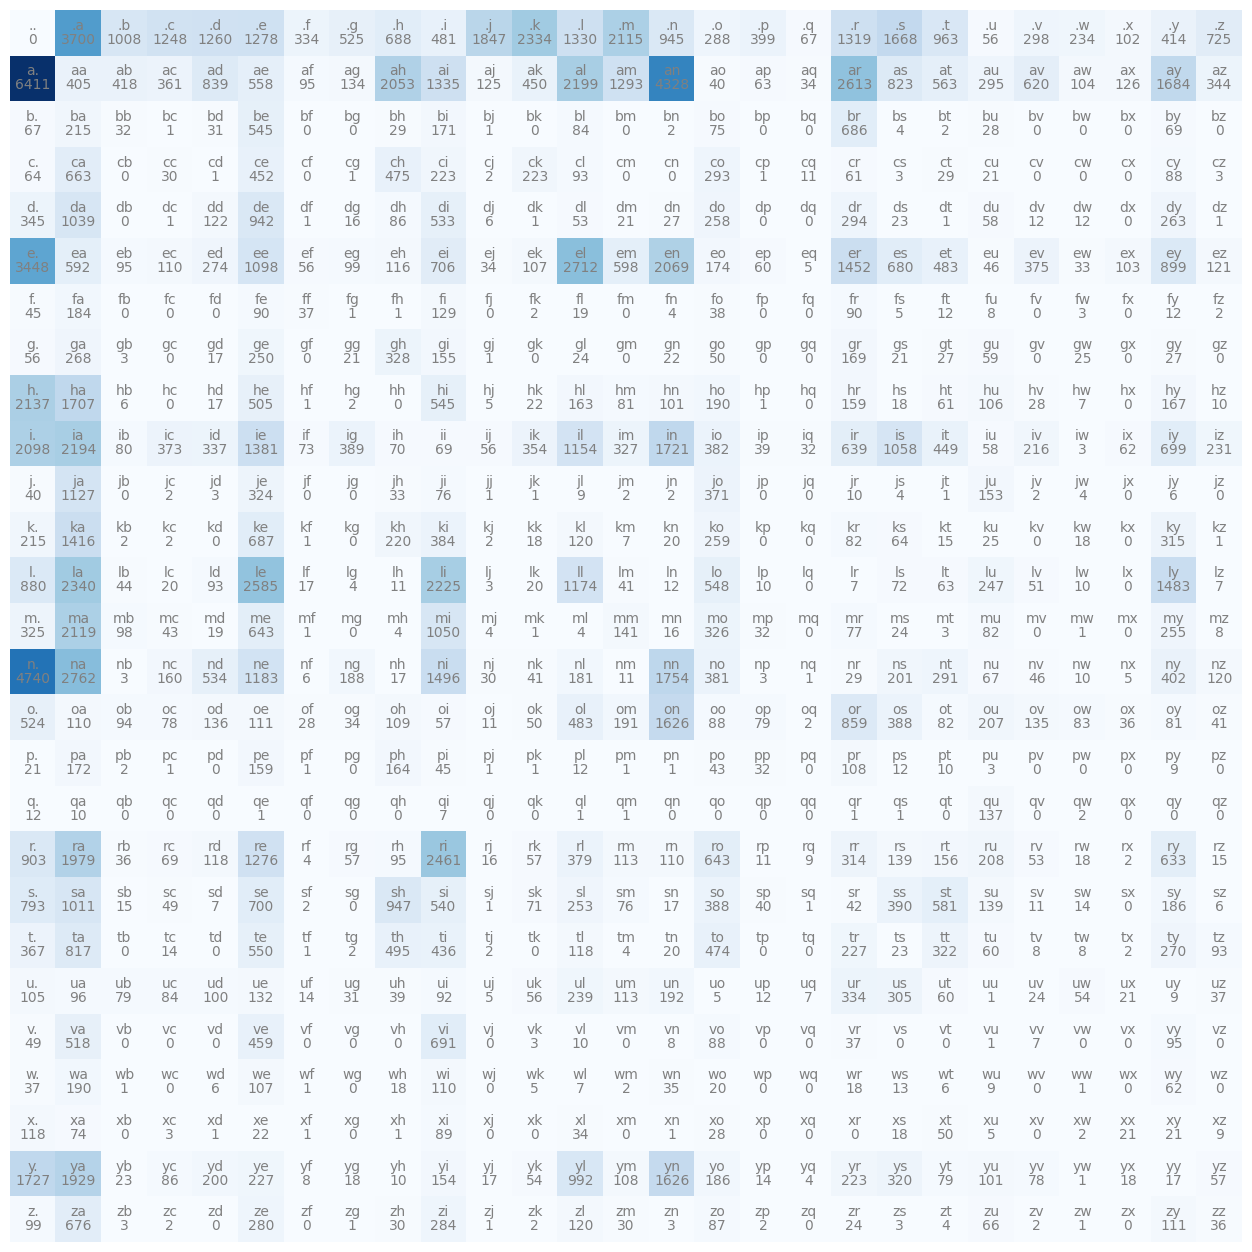

In [54]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(counts, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = index_to_char[i] + index_to_char[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, counts[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

### Turning these counts into probability distribution to sample from
* We need to divide by the total count for that current character
* So first we need to sum across the columns 
* Then normalize

In [ ]:
probs_distribution = (counts + 1).float()
probs_distribution /= probs_distribution.sum(dim=-1, keepdim=True)
probs_distribution.shape

torch.Size([27, 27])

### Generation
To generate full sequences, we will start with the "." token and iteratively sample the next token based on the current token's distribution. This process will continue until we sample the "." token again, indicating the end of the sequence.

Here is the step-by-step process:

1. Start with the "." token.
2. Sample the next token based on the current token's distribution.
3. Append the sampled token to the sequence.
4. Use the sampled token as the new current token.
5. Repeat steps 2-4 until the "." token is sampled again.

In [63]:
for i in range(5):
    idx = char_to_index["."]
    out = []
    while True:
        distribution = probs_distribution[idx]
        # print(f'\ndistribution: \n{distribution}\n distibution shape: {distribution.shape}')
        idx = torch.multinomial(distribution, num_samples=1, replacement=True).item()
        
        out.append(index_to_char[idx])

        if idx == 0:
            break
    print(''.join(out))

kima.
marieja.
heve.
kare.
kh.


### Evaluating the model using log-likelihood and perplexity
* The product of all these probs in the tabel is the likelihood
* The likelihood is telling us the probability of the entire dataset assigned by the model
* By convention we use the log likelihood instead of the likelihood because the product will give us a tiny number

### GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
* equivalent to maximizing the log likelihood (because log is monotonic)
* equivalent to minimizing the negative log likelihood
* equivalent to minimizing the average negative log likelihood

In [108]:
def negative_log_likelihood(n_grams, data, distribution):    
    N = 0
    log_likelihood = 0.0
    for name in data:
        chars = ['.'] + list(name) + ['.']
        
        for i in range(len(chars) - n_grams + 1):
            N += 1
            ids = ()
            
            for j in range(n_grams):
                idx = char_to_index[chars[i + j]]
                ids += (idx,)
            
            prob = distribution[ids]
            log_likelihood += torch.log(prob)
    
    nll = - log_likelihood       
    return nll, N

nll, N = negative_log_likelihood(2, train, probs_distribution)
print(f'{nll=}\n{nll / N=}')     
nll, N = negative_log_likelihood(2, test, probs_distribution)
print(f'{nll=}\n{nll / N=}')     

nll=tensor(443216.4688)
nll / N=tensor(2.4249)
nll=tensor(59021.4727)
nll / N=tensor(2.5961)


### Perplexity
* It is common to report log-likelihood in terms of perplexity

In [109]:
def perplexity(n_grams, data, distribution):
    nll, N = negative_log_likelihood(n_grams, data, distribution)
    return torch.exp(nll / N).item()

print(f'train loss: {perplexity(n_grams, train, probs_distribution)}\ntest loss: {perplexity(n_grams, test, probs_distribution)}')

train loss: 11.300981521606445
test loss: 13.4108247756958
